# 上机实践作业05
> 班级：信息2301  姓名：洪菁曼  学号：2310650118

![上机实践05.png](hw_doc/上机实践05.png)


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import chardet

## 1

In [ ]:
file_path = './data/Weatherquality.csv'

# 获取编码
with open(file_path, 'rb') as f:
    encoding = chardet.detect(f.read())['encoding']

# 使用编码读取
wdata = pd.read_csv(file_path, encoding=encoding)

wdata.head()

,日期,AQI,质量等级,PM$\mathrm{_{2.5}}$,PM10,S$\mathrm{O_2}$,CO,N$\mathrm{O_2}$,O3_8h
0,2019/1/1,64,良,46,37,5,0.7,24,37
1,2019/1/2,100,良,75,0,6,1.0,33,41
2,2019/1/3,98,良,73,72,5,1.0,46,12
3,2019/1/4,63,良,45,25,4,1.0,31,23
4,2019/1/5,188,中度污染,141,0,5,1.2,35,42


In [ ]:
fdata.columns

Index(['日期', 'AQI', '质量等级', 'PM$\mathrm{_{2.5}}$', 'PM10', 'S$\mathrm{O_2}$',
       'CO', 'N$\mathrm{O_2}$', 'O3_8h'],
      dtype='str')

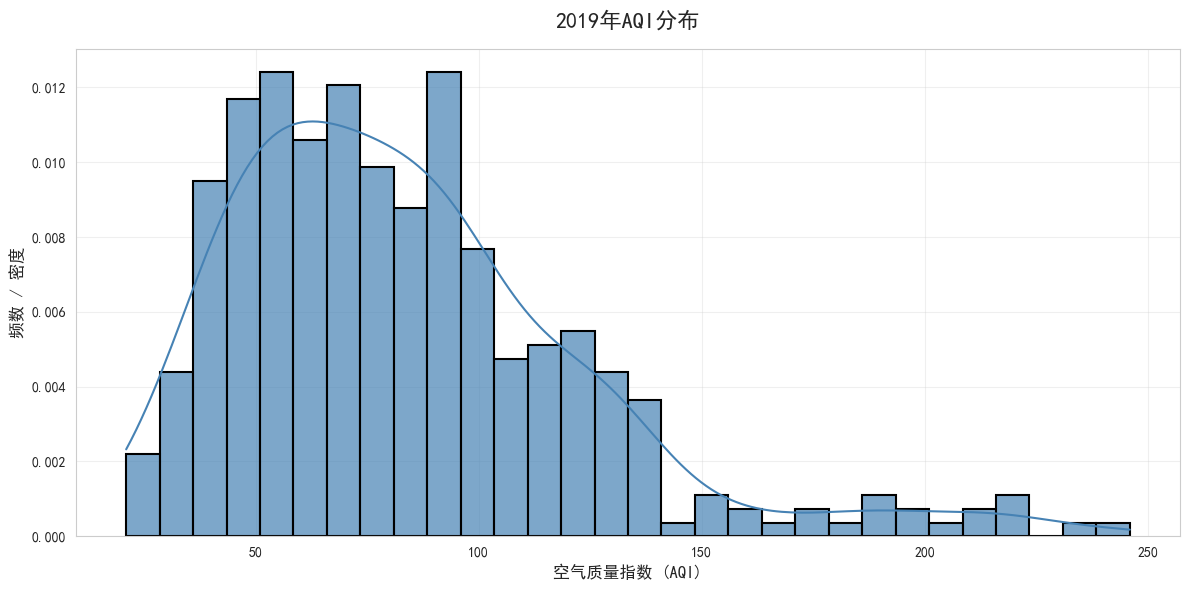

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


plt.figure(figsize=(12, 6))
# hist=True: 显示直方图, kde=True: 显示核密度估计曲线
sns.histplot(data=fdata, x='AQI', bins=30, kde=True, stat='density', color='steelblue', 
             edgecolor='black', alpha=0.7, linewidth=1.5)

plt.title('2019年AQI分布', fontsize=16, fontweight='bold', pad=15)

plt.xlabel('空气质量指数 (AQI)', fontsize=12)
plt.ylabel('频数 / 密度', fontsize=12)

plt.grid(True, alpha=0.3)

# 显示图形
plt.tight_layout()
plt.show()

明显的右偏分布

## 2

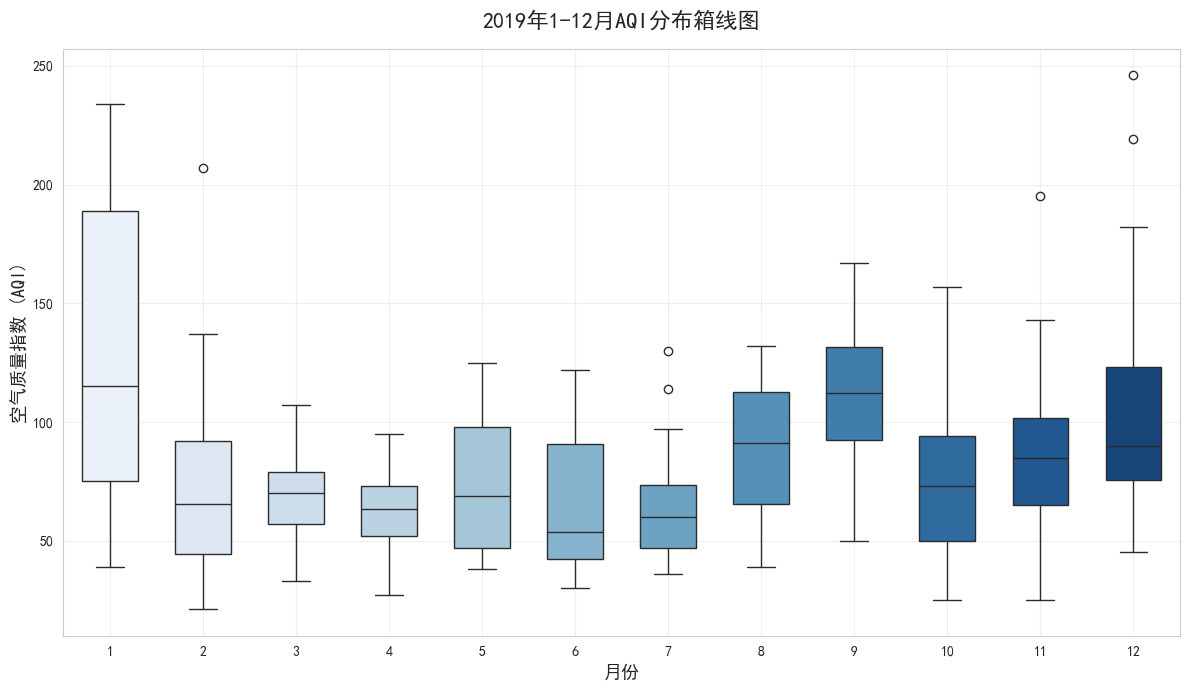

In [ ]:
# 将日期列转换为datetime类型并提取月份
fdata['日期'] = pd.to_datetime(fdata['日期'])
fdata['月份'] = wdata['日期'].dt.month

# 创建图形
plt.figure(figsize=(12, 7))

# 绘制箱线图
ax = sns.boxplot(data=wdata, x='月份', y='AQI', palette='Blues', width=0.6)

# 设置标题和标签
plt.title('2019年1-12月AQI分布箱线图', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('月份', fontsize=13)
plt.ylabel('空气质量指数 (AQI)', fontsize=13)

# 添加网格
plt.grid(True, alpha=0.3)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

## 3

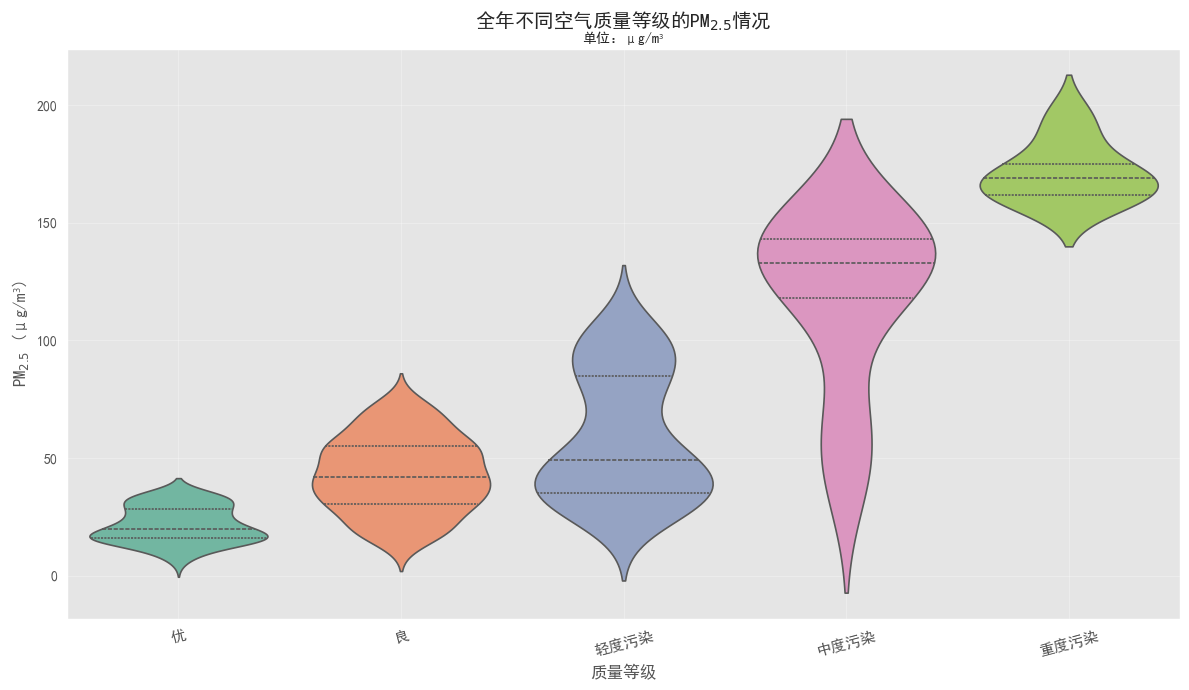

In [ ]:
pm25_col = 'PM$\mathrm{_{2.5}}$'  # PM2.5列名
quality_col = '质量等级'  # 质量等级列名

# 删除PM2.5为0的异常数据（如果有）
fdata_clean = wdata[wdata[pm25_col] > 0].copy()

# 设置绘图风格为ggplot
plt.style.use('ggplot')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

# 创建图形
fig, ax = plt.subplots(figsize=(12, 7))

# 绘制小提琴图
# 定义质量等级的顺序（从好到差）
quality_order = ['优', '良', '轻度污染', '中度污染', '重度污染', '严重污染']
# 只保留数据中存在的等级
existing_qualities = [q for q in quality_order if q in fdata_clean[quality_col].values]
# 添加可能存在但不在预定义顺序中的等级
other_qualities = [q for q in fdata_clean[quality_col].unique() if q not in existing_qualities]
quality_order_final = existing_qualities + other_qualities

# 绘制小提琴图
sns.violinplot(data=fdata_clean, x=quality_col, y=pm25_col, 
               order=quality_order_final,  # 指定顺序
               palette='Set2',  # 配色方案
               inner='quartile',  # 显示四分位数
               scale='width',  # 小提琴宽度按样本数比例缩放
               linewidth=1.2,
               ax=ax)

# 设置标题
ax.set_title('全年不同空气质量等级的PM$\mathrm{_{2.5}}$情况', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('质量等级', fontsize=12, fontweight='bold')
ax.set_ylabel('PM$\mathrm{_{2.5}}$ (μg/m$^{_{3}}$)', fontsize=12, fontweight='bold')

# 添加副标题
ax.text(0.5, 1.01, '单位：μg/m$^{_{3}}$', fontsize=10, ha='center', 
        transform=ax.transAxes, style='italic')

ax.set_xticklabels(quality_order_final, fontsize=11, rotation=15)
# 添加网格线（可选，ggplot风格自带网格）
ax.grid(True, alpha=0.3)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

## 4

In [ ]:
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

file_path = './data/tips.xls'
fdata = pd.read_excel(file_path)
print(fdata.head())

print("\n数据形状:", fdata.shape)
print("\n缺失值统计:\n", fdata.isnull().sum())
print("\n数据类型:\n", fdata.dtypes)


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

数据形状: (244, 7)

缺失值统计:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

数据类型:
 total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object


### (1) 小费金额的统计直方图与核密度估计图

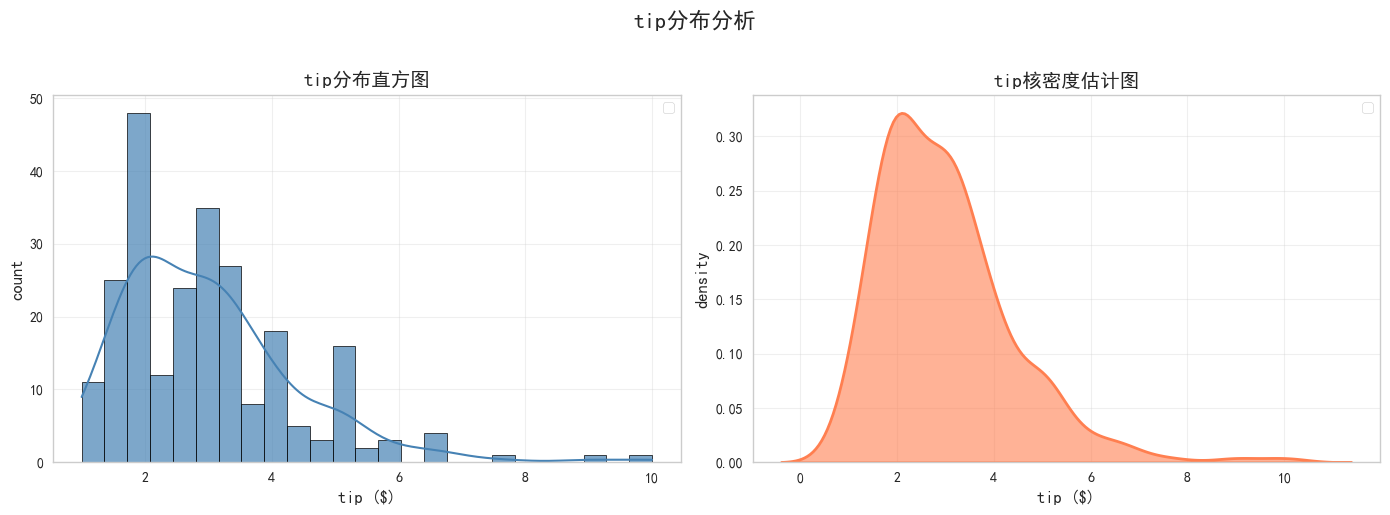

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 左图：直方图
sns.histplot(data=fdata, x='tip', bins=25, kde=True, color='steelblue', 
             edgecolor='black', alpha=0.7, ax=axes[0])
axes[0].set_title('tip分布直方图', fontsize=14, fontweight='bold')
axes[0].set_xlabel('tip ($)', fontsize=12)
axes[0].set_ylabel('count', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：核密度估计图
sns.kdeplot(data=fdata, x='tip', color='coral', fill=True, alpha=0.6, 
            linewidth=2, ax=axes[1])
axes[1].set_title('tip核密度估计图', fontsize=14, fontweight='bold')
axes[1].set_xlabel('tip ($)', fontsize=12)
axes[1].set_ylabel('density', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('tip分布分析', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


- 小费金额呈右偏分布，大部分小费集中在 $2-$4 之间
- 存在较多异常高值（慷慨顾客），最高小费达 $10

### (2) 分析男性顾客和女性顾客谁更慷慨

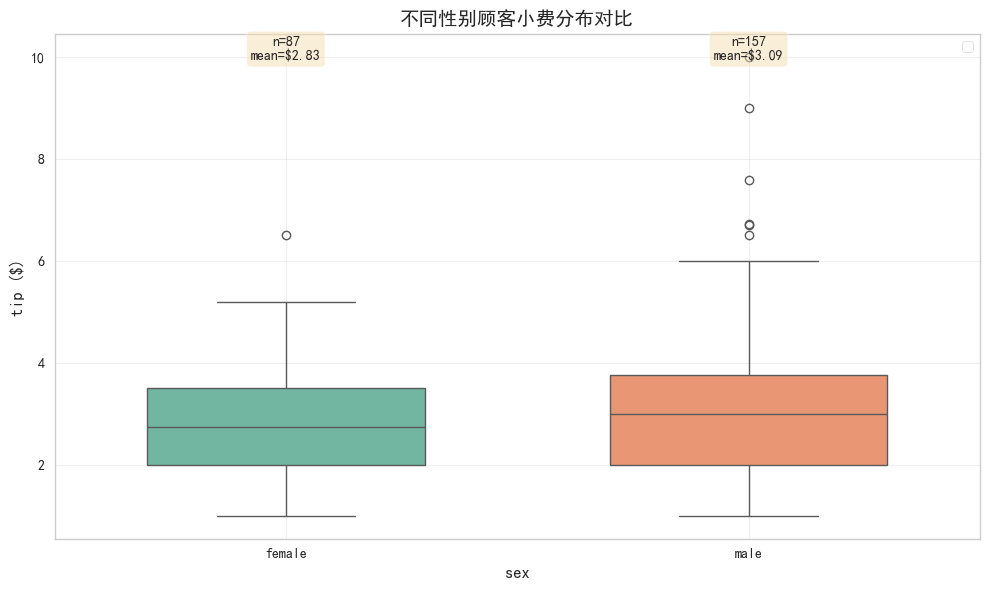


性别与小费金额统计分析

female:
  n: 87
  mean: $2.83
  median: $2.75
  std: $1.16

male:
  n: 157
  mean: $3.09
  median: $3.00
  std: $1.49

独立样本t检验结果:
  t统计量: 1.3879
  p值: 0.1665
  结论: 无显著差异


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制箱线图
sns.boxplot(data=fdata, x='sex', y='tip', palette='Set2', width=0.6, ax=ax)

# 设置标题和标签
ax.set_title('不同性别顾客小费分布对比', fontsize=14, fontweight='bold')
ax.set_xlabel('sex', fontsize=12)
ax.set_ylabel('tip ($)', fontsize=12)
ax.set_xticklabels(['female', 'male'])

# 添加统计信息标注
female_stats = fdata[fdata['sex'] == 'Female']['tip']
male_stats = fdata[fdata['sex'] == 'Male']['tip']
ax.text(0, ax.get_ylim()[1]*0.95, f'n={len(female_stats)}\nmean=${female_stats.mean():.2f}', 
        ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(1, ax.get_ylim()[1]*0.95, f'n={len(male_stats)}\nmean=${male_stats.mean():.2f}', 
        ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 统计分析结果
print("\n" + "="*60)
print("性别与小费金额统计分析")
print("\nfemale:")
print(f"  n: {len(female_stats)}")
print(f"  mean: ${female_stats.mean():.2f}")
print(f"  median: ${female_stats.median():.2f}")
print(f"  std: ${female_stats.std():.2f}")
print("\nmale:")
print(f"  n: {len(male_stats)}")
print(f"  mean: ${male_stats.mean():.2f}")
print(f"  median: ${male_stats.median():.2f}")
print(f"  std: ${male_stats.std():.2f}")

# 进行假设检验（t检验）
from scipy import stats
t_stat, p_value = stats.ttest_ind(male_stats, female_stats)
print(f"\n独立样本t检验结果:")
print(f"  t统计量: {t_stat:.4f}")
print(f"  p值: {p_value:.4f}")
if p_value < 0.05:
    print("  结论: 存在显著差异")
else:
    print("  结论: 无显著差异")


- 男性顾客平均小费: $3.09，女性顾客平均小费: $2.83
- 男性顾客小费中位数: $3.00，女性顾客小费中位数: $2.75
- 结论: Male 顾客整体更慷慨

### (3) 分析星期和小费的关系（箱线图）

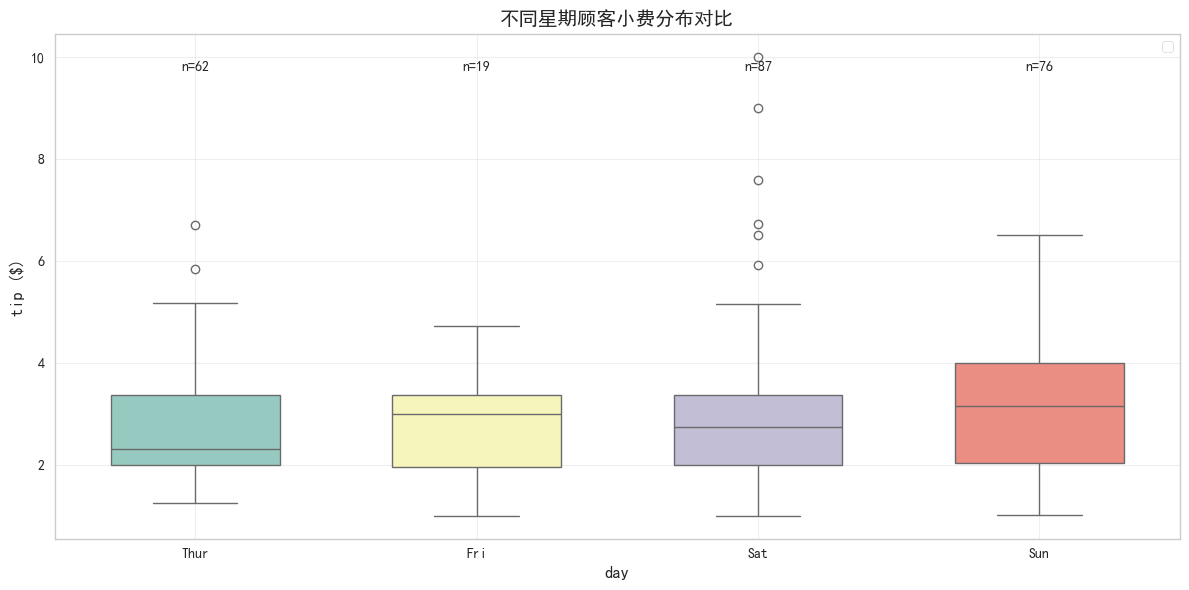

      mean  median   std  count
Thur  2.73    3.00  1.02     19
Fri   2.99    2.75  1.63     87
Sat   3.26    3.15  1.23     76
Sun   2.77    2.30  1.24     62


In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

# 定义星期顺序
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

# 绘制箱线图
sns.boxplot(data=fdata, x='day', y='tip', order=day_order, palette='Set3', width=0.6, ax=ax)

# 设置标题和标签
ax.set_title('不同星期顾客小费分布对比', fontsize=14, fontweight='bold')
ax.set_xlabel('day', fontsize=12)
ax.set_ylabel('tip ($)', fontsize=12)
ax.set_xticklabels(day_order)

# 添加样本量标注
for i, day in enumerate(day_order):
    n_count = len(fdata[fdata['day'] == day])
    ax.text(i, ax.get_ylim()[1]*0.93, f'n={n_count}', ha='center', fontsize=10)

ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 星期统计
day_stats = fdata.groupby('day')['tip'].agg(['mean', 'median', 'std', 'count'])
day_stats.index = day_order
print(day_stats.round(2))


- 周末（周六、周日）用餐人数较多，小费分布范围更广
- 周四（工作日）小费金额相对较低且集中

### (4) 按性别分析星期和小费的关系（小提琴图）

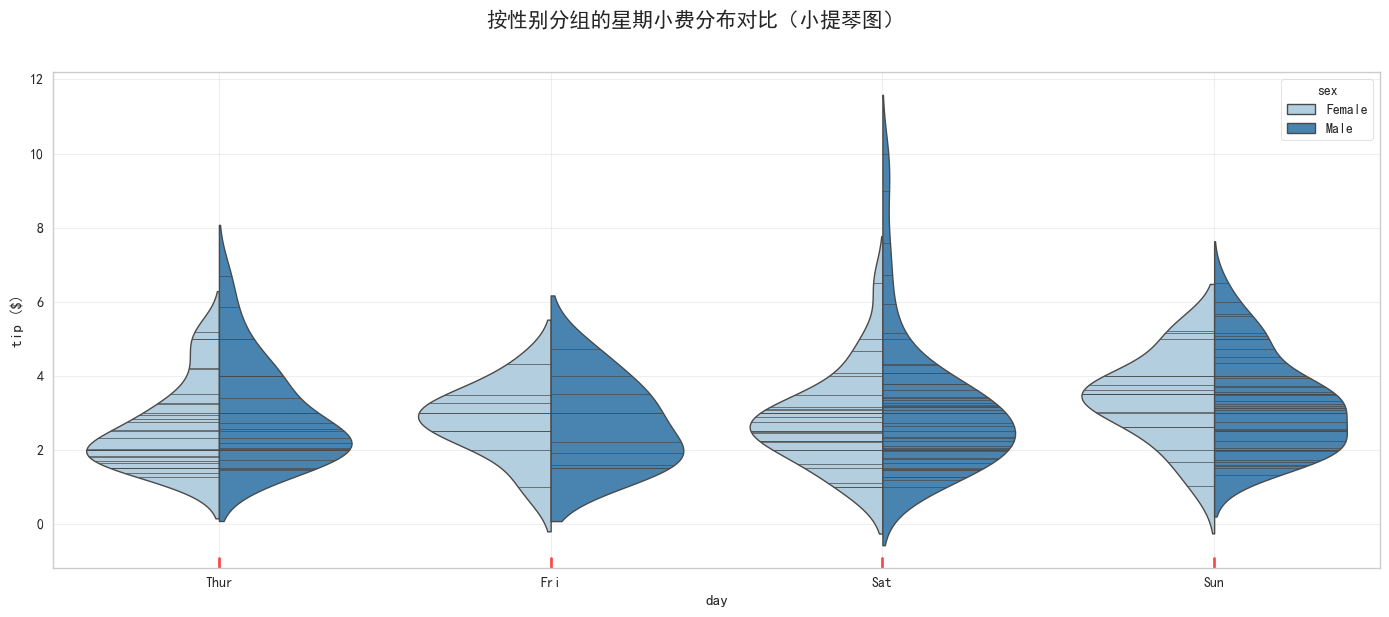

             mean  median  count
Female-Fri   2.78    3.00      9
Female-Sat   2.80    2.62     28
Female-Sun   3.37    3.50     18
Female-Thur  2.58    2.00     32
Male-Fri     2.69    2.60     10
Male-Sat     3.08    3.00     59
Male-Sun     3.22    3.08     58
Male-Thur    2.98    2.53     30


In [25]:
fig, axes = plt.subplots(figsize=(14, 6))

# 定义星期顺序
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

# 女性顾客
sns.violinplot(data=fdata, x='day', y='tip', hue='sex',
               order=day_order, palette='Blues',
               split=True,  # 不分裂，并排显示
               inner='stick',   # 内部显示箱线图
               scale='width', linewidth=1)
#axes[0].set_title('Female', fontsize=13, fontweight='bold')
axes.set_xlabel('day', fontsize=11)
axes.set_ylabel('tip ($)', fontsize=11)
axes.set_xticklabels(day_order)
# 添加均值线
for i, day in enumerate(day_order):
    mean_val = fdata[(fdata['sex'] == 'Female') & (fdata['day'] == day)]['tip'].mean()
    if not np.isnan(mean_val):
        axes.axvline(x=i, ymin=0, ymax=0.02, color='red', linewidth=2, alpha=0.7)
axes.grid(True, alpha=0.3)


plt.suptitle('按性别分组的星期小费分布对比（小提琴图）', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 详细分组统计
group_stats = fdata.groupby(['sex', 'day'])['tip'].agg(['mean', 'median', 'count']).round(2)
group_stats.index = [f"{s}-{d}" for s, d in group_stats.index]
print(group_stats)

- 男性顾客在周末的小费金额明显高于工作日
- 女性顾客小费金额受星期影响比男性小

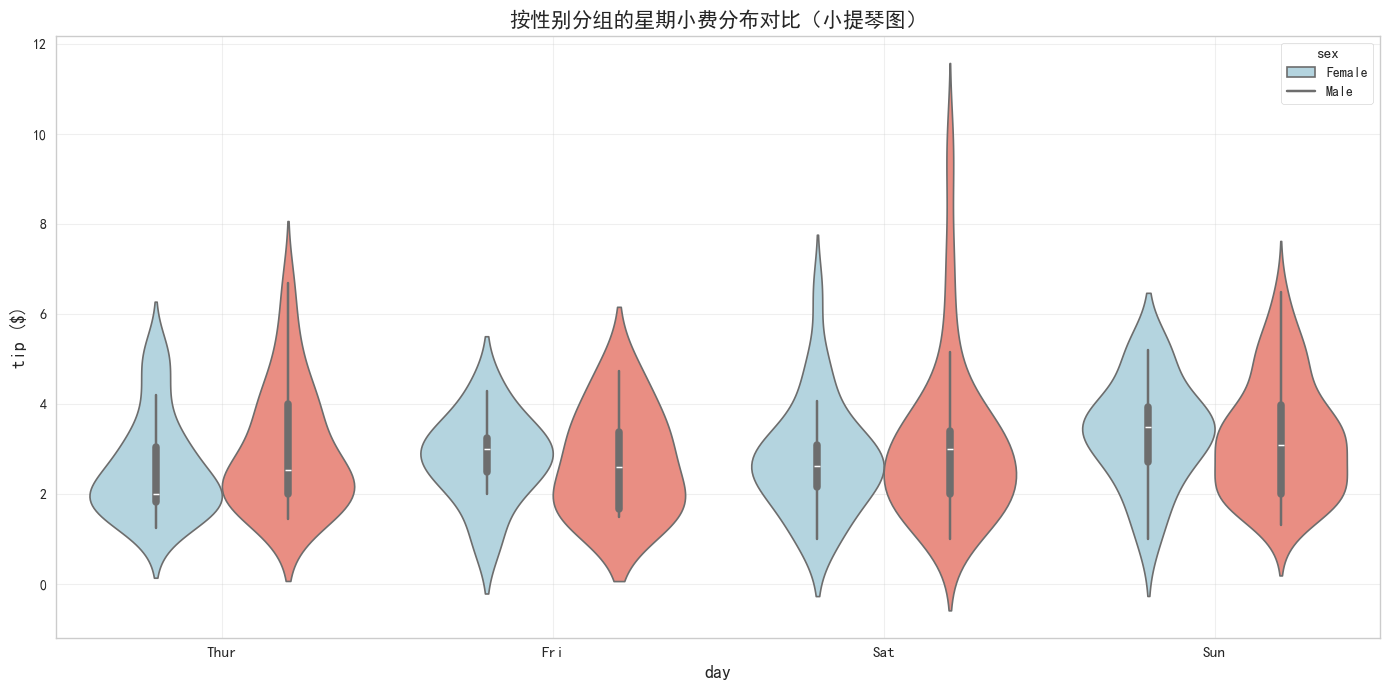


按性别和星期分组的小费统计
Female-Fri: mean=$2.78, median=$3.0, std=$0.94, count=9.0
Female-Sat: mean=$2.8, median=$2.62, std=$1.23, count=28.0
Female-Sun: mean=$3.37, median=$3.5, std=$1.14, count=18.0
Female-Thur: mean=$2.58, median=$2.0, std=$1.11, count=32.0
Male-Fri: mean=$2.69, median=$2.6, std=$1.14, count=10.0
Male-Sat: mean=$3.08, median=$3.0, std=$1.79, count=59.0
Male-Sun: mean=$3.22, median=$3.08, std=$1.27, count=58.0
Male-Thur: mean=$2.98, median=$2.53, std=$1.35, count=30.0


In [26]:
fig, ax = plt.subplots(figsize=(14, 7))

# 定义星期顺序
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

# 使用hue参数按性别分组，绘制在同一张图上
sns.violinplot(data=fdata, x='day', y='tip', hue='sex', 
               order=day_order,
               palette={'Female': 'lightblue', 'Male': 'salmon'},
               split=False,  # 不分裂，并排显示
               inner='box',   # 内部显示箱线图
               scale='width',
               linewidth=1.2,
               ax=ax)

# 计算各组的均值
mean_data = fdata.groupby(['day', 'sex'])['tip'].mean().unstack()
for i, day in enumerate(day_order):
    female_mean = mean_data.loc[day, 'Female'] if day in mean_data.index else None
    male_mean = mean_data.loc[day, 'Male'] if day in mean_data.index else None

# 设置标题和标签
ax.set_title('按性别分组的星期小费分布对比（小提琴图）', fontsize=15, fontweight='bold')
ax.set_xlabel('day', fontsize=13)
ax.set_ylabel('tip ($)', fontsize=13)
ax.set_xticklabels(day_order, fontsize=11)

# 设置图例
ax.legend(title='sex', labels=['Female', 'Male'], title_fontsize=11, fontsize=10)

# 添加网格
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 详细分组统计
print("\n" + "="*60)
print("按性别和星期分组的小费统计")
print("="*60)
group_stats = fdata.groupby(['sex', 'day'])['tip'].agg(['mean', 'median', 'std', 'count']).round(2)
for (sex, day), stats in group_stats.iterrows():
    print(f"{sex}-{day}: mean=${stats['mean']}, median=${stats['median']}, std=${stats['std']}, count={stats['count']}")
print("="*60)


In [27]:

# 交互效应分析
print("\n" + "="*60)
print("性别×星期交互效应分析")
# 计算每周男女小费差异
for day in day_order:
    female_mean = fdata[(fdata['sex'] == 'Female') & (fdata['day'] == day)]['tip'].mean()
    male_mean = fdata[(fdata['sex'] == 'Male') & (fdata['day'] == day)]['tip'].mean()
    diff = male_mean - female_mean
    print(f"{day}: 男性比女性平均多给 ${diff:.2f}")
print("="*60)


性别×星期交互效应分析
Thur: 男性比女性平均多给 $0.40
Fri: 男性比女性平均多给 $-0.09
Sat: 男性比女性平均多给 $0.28
Sun: 男性比女性平均多给 $-0.15
